# IMDB Sentiment Classification with a Bidirectional LSTM

This notebook compares five input configurations using a **Bidirectional LSTM (BiLSTM)**:

| Input representation | Variant |
|---|---|
| TF-IDF | Saved document vectors |
| GloVe | Frozen embeddings |
| GloVe | Fine-tuned embeddings |
| Word2Vec | Frozen embeddings |
| Word2Vec | Fine-tuned embeddings |

The vocabulary, encoded sequences, saved embeddings, data splits, architecture settings, and random seed are shared with the other sequence-model notebooks for a fair comparison.

## 1. Setup and reproducibility

We fix the random seed so that model initialization and batch shuffling are reproducible. CUDA is used automatically when available.

In [1]:
from pathlib import Path
import copy
import gc
import pickle
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

from scipy.sparse import load_npz
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# One global seed is used by every random-number generator in this notebook.
SEED = 42


def set_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)

    # Make CUDA LSTM operations as reproducible as possible.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def make_torch_generator():
    generator = torch.Generator()
    generator.manual_seed(SEED)
    return generator


set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Load the shared vocabulary and encoded sequences

- `vocabulary.pkl` contains `word_to_idx` and the common maximum sequence length.
- `sequence_data.npz` contains the padded sequences, true sequence lengths, and labels.
- The lengths are needed by `pack_padded_sequence`, which prevents the BiLSTM from treating padding as real text.

In [3]:
PROJECT_ROOT = Path.cwd().parent.parent
DATA_DIR = PROJECT_ROOT / "data"
SHARED_DIR = DATA_DIR / "shared"
SHARED_MODELS_DIR = SHARED_DIR / "models"
SHARED_TFIDF_DIR = SHARED_DIR / "tfidf"

MODELS_DIR = Path("models")
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(SHARED_DIR / "vocabulary.pkl", "rb") as file:
    vocab = pickle.load(file)

word_to_idx = vocab["word_to_idx"]
MAX_LENGTH = vocab["MAX_LENGTH"]
PAD_IDX = word_to_idx["<PAD>"]

sequence_data = np.load(SHARED_DIR / "sequence_data.npz")

train_padded = sequence_data["train_padded"]
val_padded = sequence_data["val_padded"]
test_padded = sequence_data["test_padded"]

train_lengths = sequence_data["train_lengths"]
val_lengths = sequence_data["val_lengths"]
test_lengths = sequence_data["test_lengths"]

y_train = sequence_data["y_train"]
y_val = sequence_data["y_val"]
y_test = sequence_data["y_test"]

print(f"Vocabulary size: {len(word_to_idx):,}")
print(f"Maximum sequence length: {MAX_LENGTH}")
print(f"Train: {train_padded.shape} | Validation: {val_padded.shape} | Test: {test_padded.shape}")

Vocabulary size: 60,725
Maximum sequence length: 321
Train: (19923, 321) | Validation: (4981, 321) | Test: (24801, 321)


## 3. PyTorch datasets and data loaders

In [4]:
class ReviewDataset(Dataset):
    def __init__(self, sequences, lengths, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.lengths = torch.tensor(lengths, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        return (
            self.sequences[index],
            self.lengths[index],
            self.labels[index]
        )


BATCH_SIZE = 32
TRAIN_LOADER_GENERATOR = make_torch_generator()

train_dataset = ReviewDataset(train_padded, train_lengths, y_train)
val_dataset = ReviewDataset(val_padded, val_lengths, y_val)
test_dataset = ReviewDataset(test_padded, test_lengths, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=TRAIN_LOADER_GENERATOR,
    num_workers=0,
    pin_memory=device.type == "cuda"
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

sequences_batch, lengths_batch, labels_batch = next(iter(train_loader))
print("Sequence batch:", sequences_batch.shape)
print("Length batch:", lengths_batch.shape)
print("Label batch:", labels_batch.shape)

Sequence batch: torch.Size([32, 321])
Length batch: torch.Size([32])
Label batch: torch.Size([32])


## 4. Load the saved input representations

The LSTM notebook already created the Word2Vec model and TF-IDF matrices. This notebook only loads those saved artifacts. GloVe is loaded from its pretrained source because it is not trained on our IMDB data.

GloVe and Word2Vec provide a vector for each token and therefore preserve word order. TF-IDF provides one vector for the entire review, so it is handled by a separate model below.

### 4.1 Load the saved Word2Vec model

The model is loaded from the shared repository directory. It is **not retrained** in this notebook. We only align its saved vectors with the shared `word_to_idx` vocabulary.

In [5]:
from gensim.models import Word2Vec

WORD2VEC_PATH = SHARED_MODELS_DIR / "word2vec_imdb.model"

if not WORD2VEC_PATH.exists():
    raise FileNotFoundError(
        f"Saved Word2Vec model not found at: {WORD2VEC_PATH}"
    )

word2vec_model = Word2Vec.load(str(WORD2VEC_PATH))

print("Loaded Word2Vec from:", WORD2VEC_PATH)
print("Vector dimension:", word2vec_model.vector_size)
print("Word2Vec vocabulary:", len(word2vec_model.wv))

Loaded Word2Vec from: c:\Users\User\Documents\InMind\Assignment_4\Assignment4_NLP_SequenceModels\data\shared\models\word2vec_imdb.model
Vector dimension: 100
Word2Vec vocabulary: 37953


### 4.2 Convert keyed vectors into a shared embedding matrix

The helper below is used for both Word2Vec and GloVe.

In [6]:
def build_embedding_matrix(keyed_vectors, word_to_idx):
    embedding_dim = keyed_vectors.vector_size

    # OOV vectors use their own seeded NumPy generator.
    rng = np.random.default_rng(SEED)
    matrix = rng.normal(
        loc=0.0,
        scale=0.05,
        size=(len(word_to_idx), embedding_dim)
    ).astype(np.float32)
    matrix[PAD_IDX] = 0.0

    matched_words = 0
    for word, index in word_to_idx.items():
        if word in keyed_vectors:
            matrix[index] = keyed_vectors[word]
            matched_words += 1

    coverage = matched_words / len(word_to_idx) * 100
    return matrix, matched_words, coverage


word2vec_embedding_matrix, word2vec_matches, word2vec_coverage = (
    build_embedding_matrix(word2vec_model.wv, word_to_idx)
)

print("Word2Vec matrix:", word2vec_embedding_matrix.shape)
print(f"Matched words: {word2vec_matches:,}")
print(f"Coverage: {word2vec_coverage:.2f}%")

Word2Vec matrix: (60725, 100)
Matched words: 37,953
Coverage: 62.50%


### 4.3 Pretrained GloVe

GloVe is loaded from `glove-wiki-gigaword-100`. Unlike our Word2Vec model, it was trained beforehand on a large general-domain corpus. This comparison lets us test whether broad pretrained knowledge or IMDB-specific local context works better for sentiment classification.

In [7]:
import gensim.downloader as api

start_time = time.time()
glove_model = api.load("glove-wiki-gigaword-100")
print(f"GloVe loaded in {(time.time() - start_time) / 60:.2f} minutes.")

glove_embedding_matrix, glove_matches, glove_coverage = (
    build_embedding_matrix(glove_model, word_to_idx)
)

print("GloVe matrix:", glove_embedding_matrix.shape)
print(f"Matched words: {glove_matches:,}")
print(f"Coverage: {glove_coverage:.2f}%")

GloVe loaded in 0.43 minutes.
GloVe matrix: (60725, 100)
Matched words: 49,464
Coverage: 81.46%


In [8]:
embedding_summary = pd.DataFrame([
    {
        "Embedding": "GloVe",
        "Dimension": glove_embedding_matrix.shape[1],
        "Matched Words": glove_matches,
        "Coverage (%)": glove_coverage
    },
    {
        "Embedding": "Word2Vec",
        "Dimension": word2vec_embedding_matrix.shape[1],
        "Matched Words": word2vec_matches,
        "Coverage (%)": word2vec_coverage
    }
])

embedding_summary

,Embedding,Dimension,Matched Words,Coverage (%)
0,GloVe,100,49464,81.455743
1,Word2Vec,100,37953,62.499794


### 4.4 Load the saved TF-IDF matrices

The TF-IDF vectorizer was fitted only on the training split in the LSTM notebook, and the validation and test sets were transformed using that fitted vectorizer. We load the saved sparse matrices directly to preserve the exact same representation and avoid data leakage.

In [9]:
TFIDF_VECTORIZER_PATH = SHARED_TFIDF_DIR / "tfidf_vectorizer.pkl"

with open(TFIDF_VECTORIZER_PATH, "rb") as file:
    tfidf_vectorizer = pickle.load(file)

X_train_tfidf = load_npz(SHARED_TFIDF_DIR / "X_train_tfidf.npz")
X_val_tfidf = load_npz(SHARED_TFIDF_DIR / "X_val_tfidf.npz")
X_test_tfidf = load_npz(SHARED_TFIDF_DIR / "X_test_tfidf.npz")

assert X_train_tfidf.shape[0] == len(y_train)
assert X_val_tfidf.shape[0] == len(y_val)
assert X_test_tfidf.shape[0] == len(y_test)
assert X_train_tfidf.shape[1] == len(tfidf_vectorizer.vocabulary_)

print("Loaded TF-IDF from:", SHARED_TFIDF_DIR)
print("Train:", X_train_tfidf.shape)
print("Validation:", X_val_tfidf.shape)
print("Test:", X_test_tfidf.shape)

c:\Users\User\anaconda3\envs\ML-academy\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\User\anaconda3\envs\ML-academy\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded TF-IDF from: c:\Users\User\Documents\InMind\Assignment_4\Assignment4_NLP_SequenceModels\data\shared\tfidf
Train: (19923, 20000)
Validation: (4981, 20000)
Test: (24801, 20000)


### 4.5 TF-IDF datasets and loaders

The matrices remain sparse in memory. Only the rows requested for the current batch are converted to dense tensors.

In [10]:
class TfidfDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = np.asarray(labels, dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        feature = self.features[index].toarray().squeeze(0)
        return (
            torch.tensor(feature, dtype=torch.float32),
            torch.tensor(self.labels[index], dtype=torch.float32)
        )


TFIDF_BATCH_SIZE = 32
TFIDF_LOADER_GENERATOR = make_torch_generator()

tfidf_train_dataset = TfidfDataset(X_train_tfidf, y_train)
tfidf_val_dataset = TfidfDataset(X_val_tfidf, y_val)
tfidf_test_dataset = TfidfDataset(X_test_tfidf, y_test)

tfidf_train_loader = DataLoader(
    tfidf_train_dataset,
    batch_size=TFIDF_BATCH_SIZE,
    shuffle=True,
    generator=TFIDF_LOADER_GENERATOR,
    num_workers=0,
    pin_memory=device.type == "cuda"
)
tfidf_val_loader = DataLoader(
    tfidf_val_dataset,
    batch_size=TFIDF_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)
tfidf_test_loader = DataLoader(
    tfidf_test_dataset,
    batch_size=TFIDF_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=device.type == "cuda"
)

tfidf_features_batch, tfidf_labels_batch = next(iter(tfidf_train_loader))
print("TF-IDF feature batch:", tfidf_features_batch.shape)
print("TF-IDF label batch:", tfidf_labels_batch.shape)

TF-IDF feature batch: torch.Size([32, 20000])
TF-IDF label batch: torch.Size([32])


## 5. Bidirectional LSTM architectures

The GloVe and Word2Vec model reads token vectors in both directions and concatenates the final forward and backward states.

TF-IDF is different: each review is already summarized as one document vector. To stay consistent with the LSTM notebook, that vector is presented to a separate BiLSTM as a sequence of length one. This permits architectural comparison, but bidirectionality cannot recover word order that TF-IDF has already discarded.

In [11]:
class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        embedding_matrix,
        hidden_size=128,
        num_layers=1,
        dropout=0.3,
        freeze_embeddings=True
    ):
        super().__init__()

        embedding_tensor = torch.tensor(
            embedding_matrix,
            dtype=torch.float32
        )
        self.embedding = nn.Embedding.from_pretrained(
            embedding_tensor,
            freeze=freeze_embeddings,
            padding_idx=PAD_IDX
        )

        embedding_dim = embedding_matrix.shape[1]
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_size * 2, 1)

    def forward(self, sequences, lengths):
        embedded = self.embedding(sequences)

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        review_representation = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1
        )

        logits = self.output(
            self.dropout(review_representation)
        ).squeeze(1)
        return logits

### TF-IDF BiLSTM

The input shape changes from `[batch, features]` to `[batch, 1, features]`. Because the sequence has one step, the forward and backward states process the same document vector with separate parameters.

In [12]:
class TfidfBiLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=1,
        dropout=0.3
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.output = nn.Linear(hidden_size * 2, 1)

    def forward(self, features):
        features = features.unsqueeze(1)
        _, (hidden, _) = self.lstm(features)

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]
        document_representation = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1
        )

        logits = self.output(
            self.dropout(document_representation)
        ).squeeze(1)
        return logits

## 6. Training and evaluation utilities

The same functions train all four variants. We clip gradients at a norm of 1.0 to reduce exploding gradients and retain the checkpoint with the lowest validation loss. Early stopping prevents continued training once validation performance stops improving.

The test set is not used for checkpoint selection. It is evaluated only after the best validation checkpoint has been restored.

In [13]:
def train_one_epoch(model, data_loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for sequences, lengths, labels in data_loader:
        sequences = sequences.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(sequences, lengths)
        loss = criterion(logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        predictions = (torch.sigmoid(logits) >= 0.5).float()
        total_loss += loss.item() * labels.size(0)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def validate_one_epoch(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(sequences, lengths)
            loss = criterion(logits, labels)
            predictions = (torch.sigmoid(logits) >= 0.5).float()

            total_loss += loss.item() * labels.size(0)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [14]:
def train_tfidf_one_epoch(model, data_loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for features, labels in data_loader:
        features = features.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        predictions = (torch.sigmoid(logits) >= 0.5).float()
        total_loss += loss.item() * labels.size(0)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def validate_tfidf_one_epoch(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(features)
            loss = criterion(logits, labels)
            predictions = (torch.sigmoid(logits) >= 0.5).float()

            total_loss += loss.item() * labels.size(0)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [15]:
def train_model(
    model,
    optimizer,
    criterion,
    checkpoint_path,
    epochs,
    patience,
    train_data_loader,
    val_data_loader,
    train_epoch_function,
    validate_epoch_function
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = train_epoch_function(
            model, train_data_loader, criterion, optimizer
        )
        val_loss, val_accuracy = validate_epoch_function(
            model, val_data_loader, criterion
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train loss {train_loss:.4f}, acc {train_accuracy:.4f} | "
            f"Val loss {val_loss:.4f}, acc {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, checkpoint_path)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping after epoch {epoch}.")
                break

    if best_state is None:
        raise RuntimeError("Training ended without a valid checkpoint.")

    model.load_state_dict(best_state)
    elapsed_seconds = time.time() - start_time
    return history, best_epoch, elapsed_seconds


def calculate_metrics(labels, predictions):
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0)
    }

In [16]:
def evaluate_model(model, data_loader):
    model.eval()
    labels_all = []
    predictions_all = []
    probabilities_all = []

    with torch.no_grad():
        for sequences, lengths, labels in data_loader:
            sequences = sequences.to(device, non_blocking=True)
            logits = model(sequences, lengths)
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).long()

            labels_all.extend(labels.numpy().astype(int))
            predictions_all.extend(predictions.cpu().numpy())
            probabilities_all.extend(probabilities.cpu().numpy())

    labels_all = np.asarray(labels_all)
    predictions_all = np.asarray(predictions_all)
    probabilities_all = np.asarray(probabilities_all)

    return (
        calculate_metrics(labels_all, predictions_all),
        labels_all,
        predictions_all,
        probabilities_all
    )


def evaluate_tfidf_model(model, data_loader):
    model.eval()
    labels_all = []
    predictions_all = []
    probabilities_all = []

    with torch.no_grad():
        for features, labels in data_loader:
            features = features.to(device, non_blocking=True)
            logits = model(features)
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= 0.5).long()

            labels_all.extend(labels.numpy().astype(int))
            predictions_all.extend(predictions.cpu().numpy())
            probabilities_all.extend(probabilities.cpu().numpy())

    labels_all = np.asarray(labels_all)
    predictions_all = np.asarray(predictions_all)
    probabilities_all = np.asarray(probabilities_all)

    return (
        calculate_metrics(labels_all, predictions_all),
        labels_all,
        predictions_all,
        probabilities_all
    )

## 7. Controlled experiments

The four sequence-embedding variants use the same BiLSTM settings. TF-IDF uses the same hidden size, layer count, dropout, optimizer, epochs, and early-stopping rule through its separate input interface.

Before each run, both the global generators and the appropriate shuffled DataLoader generator are reset to `SEED`, giving every experiment the same reproducible starting conditions.

In [17]:
HIDDEN_SIZE = 128
NUM_LAYERS = 1
DROPOUT = 0.5
LEARNING_RATE = 1e-3
EPOCHS = 10
PATIENCE = 3

EXPERIMENTS = [
    {
        "name": "GloVe Frozen",
        "embedding": "GloVe",
        "variant": "Frozen",
        "matrix": glove_embedding_matrix,
        "freeze": True,
        "checkpoint": "bilstm_glove_frozen.pt"
    },
    {
        "name": "GloVe Fine-Tuned",
        "embedding": "GloVe",
        "variant": "Fine-Tuned",
        "matrix": glove_embedding_matrix,
        "freeze": False,
        "checkpoint": "bilstm_glove_finetuned.pt"
    },
    {
        "name": "Word2Vec Frozen",
        "embedding": "Word2Vec",
        "variant": "Frozen",
        "matrix": word2vec_embedding_matrix,
        "freeze": True,
        "checkpoint": "bilstm_word2vec_frozen.pt"
    },
    {
        "name": "Word2Vec Fine-Tuned",
        "embedding": "Word2Vec",
        "variant": "Fine-Tuned",
        "matrix": word2vec_embedding_matrix,
        "freeze": False,
        "checkpoint": "bilstm_word2vec_finetuned.pt"
    }
]

In [18]:
def run_sequence_experiment(config):
    print("=" * 70)
    print("Training", config["name"], "BiLSTM")
    print("=" * 70)

    set_seed()
    TRAIN_LOADER_GENERATOR.manual_seed(SEED)

    model = BiLSTMClassifier(
        embedding_matrix=config["matrix"].copy(),
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT,
        freeze_embeddings=config["freeze"]
    ).to(device)

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=LEARNING_RATE
    )

    checkpoint_path = MODELS_DIR / config["checkpoint"]
    history, best_epoch, elapsed_seconds = train_model(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        checkpoint_path=checkpoint_path,
        epochs=EPOCHS,
        patience=PATIENCE,
        train_data_loader=train_loader,
        val_data_loader=val_loader,
        train_epoch_function=train_one_epoch,
        validate_epoch_function=validate_one_epoch
    )

    metrics, labels, predictions, probabilities = evaluate_model(
        model, test_loader
    )

    print("\nTest classification report")
    print(classification_report(
        labels,
        predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    result = {
        "Experiment": config["name"],
        "Model": "BiLSTM",
        "Embedding": config["embedding"],
        "Variant": config["variant"],
        "Trainable Parameters": trainable_parameters,
        "Best Epoch": best_epoch,
        "Training Time (min)": elapsed_seconds / 60,
        **metrics
    }

    artifacts = {
        "history": history,
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
        "checkpoint": checkpoint_path
    }

    del model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result, artifacts

In [19]:
def run_tfidf_experiment():
    experiment_name = "TF-IDF"
    print("=" * 70)
    print("Training TF-IDF BiLSTM")
    print("=" * 70)

    set_seed()
    TFIDF_LOADER_GENERATOR.manual_seed(SEED)

    model = TfidfBiLSTMClassifier(
        input_size=X_train_tfidf.shape[1],
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        dropout=DROPOUT
    ).to(device)

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    checkpoint_path = MODELS_DIR / "bilstm_tfidf.pt"
    history, best_epoch, elapsed_seconds = train_model(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        checkpoint_path=checkpoint_path,
        epochs=EPOCHS,
        patience=PATIENCE,
        train_data_loader=tfidf_train_loader,
        val_data_loader=tfidf_val_loader,
        train_epoch_function=train_tfidf_one_epoch,
        validate_epoch_function=validate_tfidf_one_epoch
    )

    metrics, labels, predictions, probabilities = evaluate_tfidf_model(
        model, tfidf_test_loader
    )

    print("\nTest classification report")
    print(classification_report(
        labels,
        predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    result = {
        "Experiment": experiment_name,
        "Model": "BiLSTM",
        "Embedding": "TF-IDF",
        "Variant": "Document Vector",
        "Trainable Parameters": trainable_parameters,
        "Best Epoch": best_epoch,
        "Training Time (min)": elapsed_seconds / 60,
        **metrics
    }

    artifacts = {
        "history": history,
        "labels": labels,
        "predictions": predictions,
        "probabilities": probabilities,
        "checkpoint": checkpoint_path
    }

    del model, optimizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result, artifacts

In [20]:
results = []
experiment_artifacts = {}

tfidf_result, tfidf_artifacts = run_tfidf_experiment()
results.append(tfidf_result)
experiment_artifacts["TF-IDF"] = tfidf_artifacts

for experiment in EXPERIMENTS:
    result, artifacts = run_sequence_experiment(experiment)
    results.append(result)
    experiment_artifacts[experiment["name"]] = artifacts

ALL_EXPERIMENT_NAMES = list(experiment_artifacts.keys())

results_df = pd.DataFrame(results).sort_values(
    "f1", ascending=False
).reset_index(drop=True)

results_df

Training TF-IDF BiLSTM
Epoch 01/10 | Train loss 0.3862, acc 0.8376 | Val loss 0.2529, acc 0.8974
Epoch 02/10 | Train loss 0.1632, acc 0.9411 | Val loss 0.2613, acc 0.8918
Epoch 03/10 | Train loss 0.0931, acc 0.9706 | Val loss 0.3125, acc 0.8824
Epoch 04/10 | Train loss 0.0529, acc 0.9859 | Val loss 0.3727, acc 0.8747
Early stopping after epoch 4.

Test classification report
              precision    recall  f1-score   support

    Negative       0.86      0.91      0.88     12361
    Positive       0.90      0.85      0.88     12440

    accuracy                           0.88     24801
   macro avg       0.88      0.88      0.88     24801
weighted avg       0.88      0.88      0.88     24801

Training GloVe Frozen BiLSTM
Epoch 01/10 | Train loss 0.5319, acc 0.7320 | Val loss 0.4303, acc 0.8069
Epoch 02/10 | Train loss 0.3969, acc 0.8256 | Val loss 0.3563, acc 0.8492
Epoch 03/10 | Train loss 0.3463, acc 0.8553 | Val loss 0.3597, acc 0.8548
Epoch 04/10 | Train loss 0.3064, acc 0.8725 |

,Experiment,Model,Embedding,Variant,Trainable Parameters,Best Epoch,Training Time (min),accuracy,precision,recall,f1
0,Word2Vec Frozen,BiLSTM,Word2Vec,Frozen,235777,8,2.501301,0.896980,0.907763,0.884486,0.895973
1,GloVe Frozen,BiLSTM,GloVe,Frozen,235777,7,2.451694,0.881981,0.898734,0.861817,0.879888
2,TF-IDF,BiLSTM,TF-IDF,Document Vector,20613377,1,0.558914,0.880368,0.902592,0.853617,0.877422
3,GloVe Fine-Tuned,BiLSTM,GloVe,Fine-Tuned,6308277,2,1.542139,0.866820,0.920479,0.803939,0.858271
4,Word2Vec Fine-Tuned,BiLSTM,Word2Vec,Fine-Tuned,6308277,2,1.458782,0.862989,0.925066,0.790916,0.852747


## 8. Results comparison

The table now includes TF-IDF alongside all four dense-embedding variants. Fine-tuned embeddings have more trainable parameters because their word vectors are updated during supervised training. TF-IDF has no embedding layer; its document-vector dimensionality instead affects the BiLSTM input weights.

Results saved to: c:\Users\User\Documents\InMind\Assignment_4\Assignment4_NLP_SequenceModels\results\bilstm_results.csv


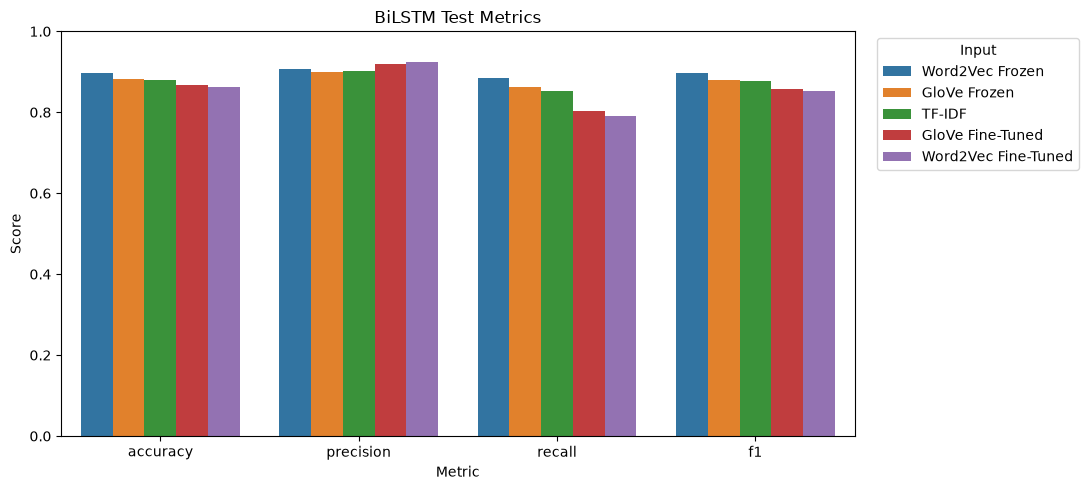

In [21]:
results_df.to_csv(
    RESULTS_DIR / "bilstm_results.csv",
    index=False
)
print("Results saved to:", RESULTS_DIR / "bilstm_results.csv")

metric_columns = ["accuracy", "precision", "recall", "f1"]
plot_df = results_df.melt(
    id_vars=["Experiment"],
    value_vars=metric_columns,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=plot_df,
    x="Metric",
    y="Score",
    hue="Experiment"
)
plt.ylim(0, 1)
plt.title("BiLSTM Test Metrics")
plt.legend(title="Input", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 8.1 Training curves

The gap between training and validation curves helps diagnose overfitting. Fine-tuned embeddings may fit the training set faster because the model can modify the word vectors themselves.

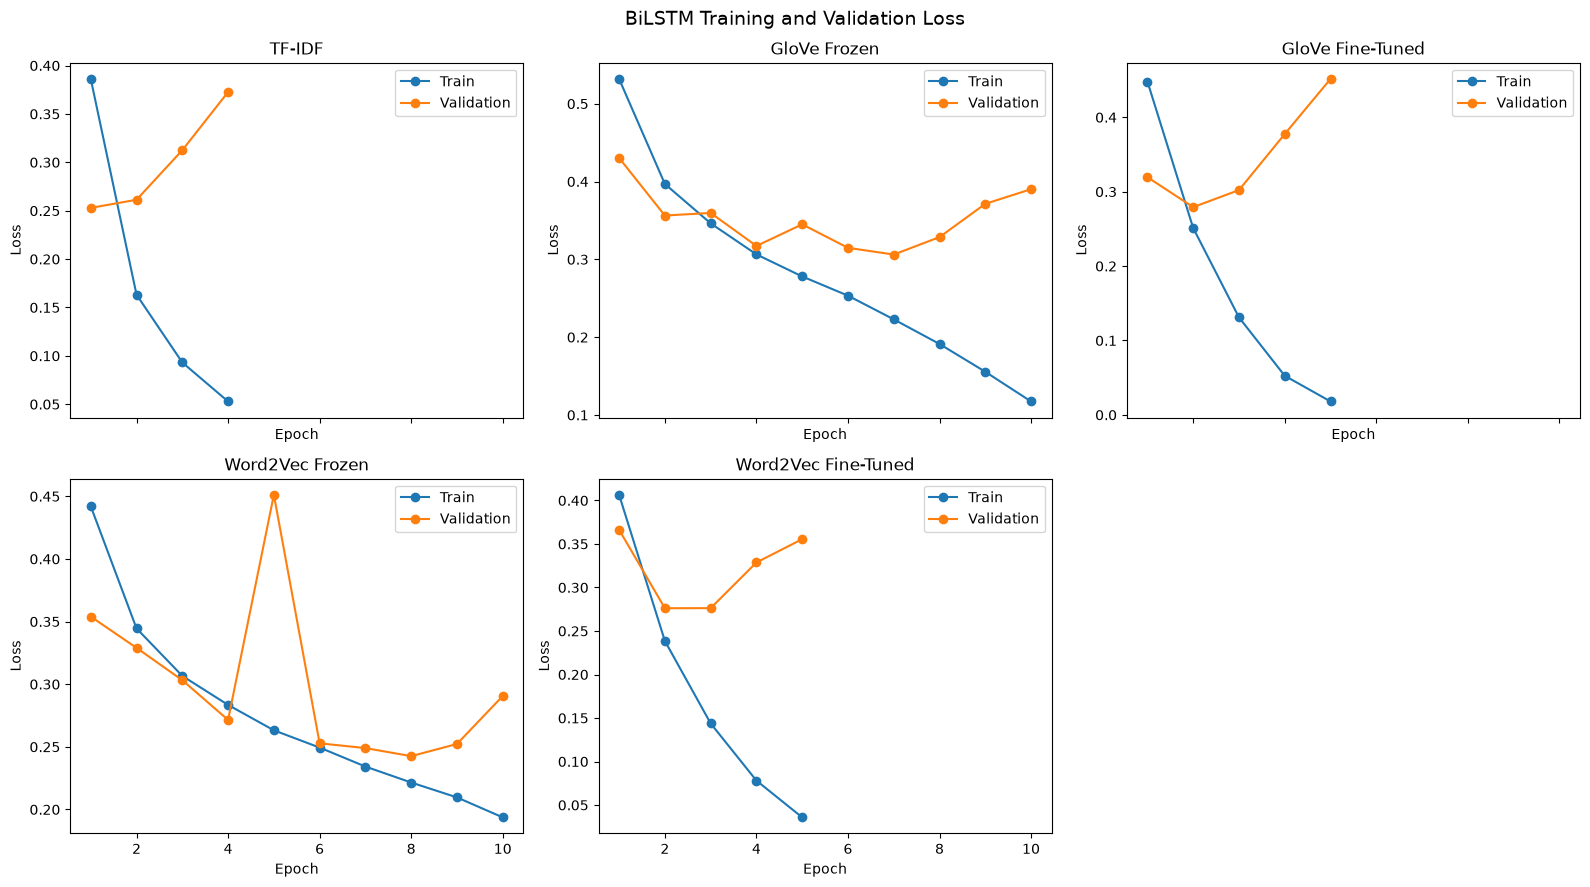

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)

for axis, name in zip(axes.flat, ALL_EXPERIMENT_NAMES):
    history = experiment_artifacts[name]["history"]
    epochs_ran = range(1, len(history["train_loss"]) + 1)

    axis.plot(epochs_ran, history["train_loss"], marker="o", label="Train")
    axis.plot(epochs_ran, history["val_loss"], marker="o", label="Validation")
    axis.set_title(name)
    axis.set_xlabel("Epoch")
    axis.set_ylabel("Loss")
    axis.legend()

for axis in axes.flat[len(ALL_EXPERIMENT_NAMES):]:
    axis.set_visible(False)

fig.suptitle("BiLSTM Training and Validation Loss", fontsize=14)
plt.tight_layout()
plt.show()

### 8.2 Confusion matrices

Each confusion matrix separates false positives from false negatives. This shows whether an embedding variant systematically favors positive or negative predictions even when its overall accuracy is similar.

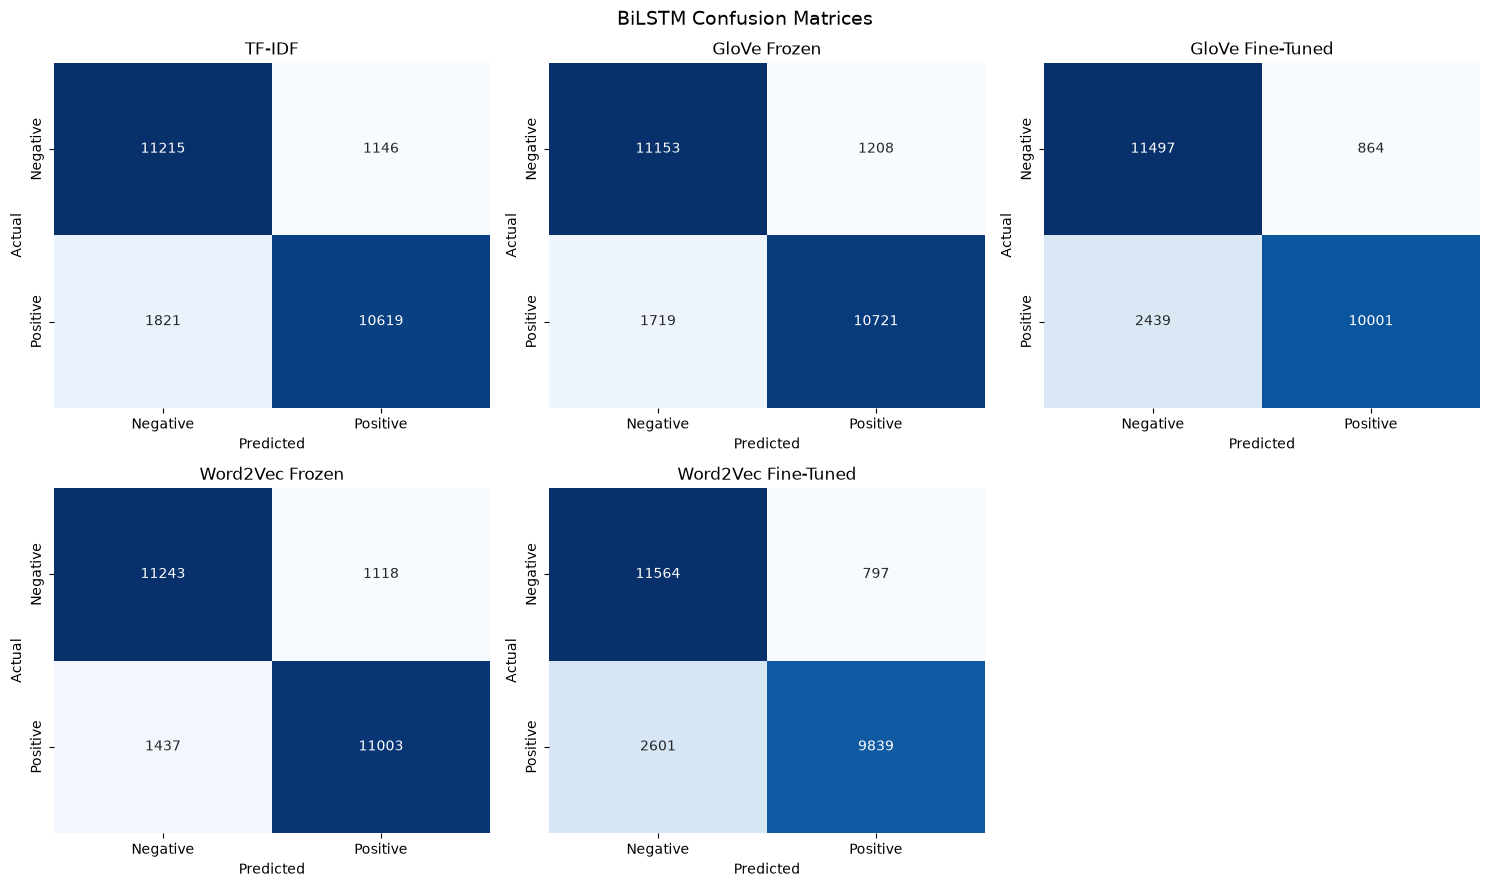

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for axis, name in zip(axes.flat, ALL_EXPERIMENT_NAMES):
    artifacts = experiment_artifacts[name]
    matrix = confusion_matrix(
        artifacts["labels"],
        artifacts["predictions"]
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        ax=axis
    )
    axis.set_title(name)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Actual")

for axis in axes.flat[len(ALL_EXPERIMENT_NAMES):]:
    axis.set_visible(False)

fig.suptitle("BiLSTM Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Error analysis of the best variant

We select the best variant by test F1 only for reporting and analysis; its checkpoint was still chosen using validation loss. We inspect its most confident mistakes because they reveal failure modes that aggregate metrics hide, such as mixed sentiment, negation, sarcasm, truncation, or rare vocabulary.

In [24]:
best_row = results_df.iloc[0]
best_name = best_row["Experiment"]
best_artifacts = experiment_artifacts[best_name]

test_df = pd.read_csv(DATA_DIR / "test_processed.csv")

error_df = pd.DataFrame({
    "processed_text": test_df["processed_text"].reset_index(drop=True),
    "true_label": best_artifacts["labels"],
    "predicted_label": best_artifacts["predictions"],
    "positive_probability": best_artifacts["probabilities"],
    "length": test_lengths
})

error_df["confidence"] = np.where(
    error_df["predicted_label"] == 1,
    error_df["positive_probability"],
    1 - error_df["positive_probability"]
)

errors = error_df[
    error_df["true_label"] != error_df["predicted_label"]
].sort_values("confidence", ascending=False)

false_positives = errors[
    (errors["true_label"] == 0) & (errors["predicted_label"] == 1)
]
false_negatives = errors[
    (errors["true_label"] == 1) & (errors["predicted_label"] == 0)
]

print("Best variant:", best_name)
print("Best checkpoint:", best_artifacts["checkpoint"])
print(f"Misclassified reviews: {len(errors):,} / {len(error_df):,}")
print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

print("\nMost confident false positives")
display(false_positives[
    ["processed_text", "positive_probability", "length"]
].head(5))

print("Most confident false negatives")
display(false_negatives[
    ["processed_text", "positive_probability", "length"]
].head(5))

Best variant: Word2Vec Frozen
Best checkpoint: models\bilstm_word2vec_frozen.pt
Misclassified reviews: 2,555 / 24,801
False positives: 1118
False negatives: 1437

Most confident false positives


,processed_text,positive_probability,length
17996,went see 3 night ago cork ireland world premie...,0.999847,143
14342,one time greatest horror movie charles band ma...,0.999754,184
16652,must say disappointed film although well acted...,0.999675,63
16449,film derives long running itv sitcom name sitc...,0.999557,118
21051,yes might not historically accurate actually 6...,0.999410,78


Most confident false negatives


,processed_text,positive_probability,length
9083,lovely yet lethal alexandra stunning statuesqu...,0.004220,161
2477,basically endearingly chintzy moronic 1 50 ver...,0.006731,186
7390,actually admit political junkie resonated erra...,0.008833,73
2252,hollywood turned mafia production line output ...,0.010139,249
7558,think crewes evil part well award anything dun...,0.010566,76


In [28]:
print(false_negatives.iloc[:5].to_numpy())

[['lovely yet lethal alexandra stunning statuesque blonde beauty stacie randall look absolutely smashing tight black leather outfit must find magic amulet evil demonic master faust cross dimension fearless rugged cop jonathan graf likable peter liapis stop meanwhile two pitifully unfunny comic relief dwarf gnome creature run amok los angeles seasoned veteran schlock exploitation expert jim wynorski relates supremely inane story brisk pace take none foolishness remotely seriously cast struggle gamely silly material adorable barbara alyn wood sassy fetching police captain kate raquel krelle tart sexy hooker jeanine bobby di cicco graf bumbling excitable partner scotty peggy trentini alluring museum curator monica ace mask jolly dr rochelle mark stevi puerile cookie cutter script amusingly lowbrow sense no brainer humor chuck cirino bouncy cornball score two dwarf guy sporting obvious cheap rubber halloween mask j e bash plain cinematography no tension gratuitous female nudity speak tacky

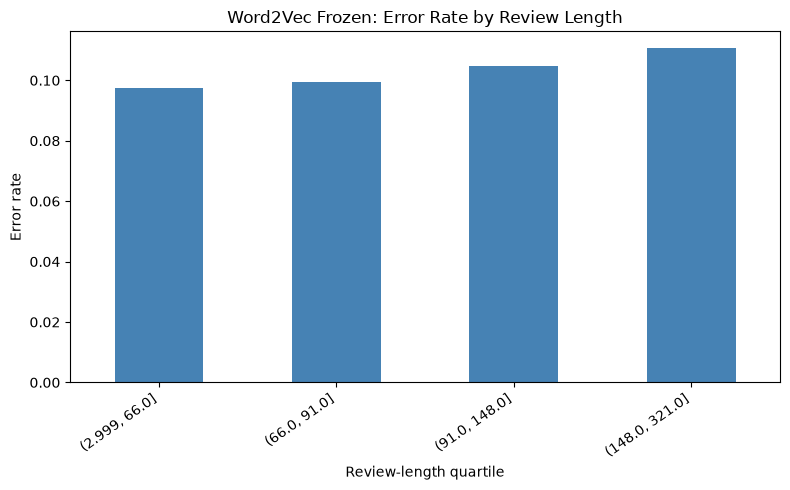

length_group
(2.999, 66.0]     0.097415
(66.0, 91.0]      0.099437
(91.0, 148.0]     0.104824
(148.0, 321.0]    0.110677
Name: is_error, dtype: float64

In [25]:
error_by_length = error_df.assign(
    is_error=error_df["true_label"] != error_df["predicted_label"],
    length_group=pd.qcut(error_df["length"], q=4, duplicates="drop")
).groupby("length_group", observed=True)["is_error"].mean()

plt.figure(figsize=(8, 5))
error_by_length.plot(kind="bar", color="steelblue")
plt.ylabel("Error rate")
plt.xlabel("Review-length quartile")
plt.title(f"{best_name}: Error Rate by Review Length")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

error_by_length